# 🔧 File 02 — Tiền xử lý dữ liệu (Preprocessing)
**Brain Tumor Classification MRI Dataset**

Mục tiêu:
- Resize ảnh về kích thước đồng nhất
- Normalize pixel về [0, 1]
- Tách Validation set từ Training set
- Data Augmentation (tăng cường dữ liệu)
- Tạo data pipeline sẵn sàng cho model

## 📦 Phần A — Import thư viện

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import warnings
warnings.filterwarnings('ignore')

print(f'✅ TensorFlow version: {tf.__version__}')

✅ TensorFlow version: 2.21.0


## ⚙️ Phần B — Cấu hình tham số

Tất cả các thông số quan trọng đặt ở đây để dễ thay đổi sau.

In [2]:
# ============================================================
# THÔNG SỐ CẤU HÌNH — chỉnh sửa tại đây
# ============================================================

DATA_DIR  = Path(r'C:\\Users\\Lenovo\\brain-tumor\\data')
TRAIN_DIR = DATA_DIR / 'Training'
TEST_DIR  = DATA_DIR / 'Testing'

# [SỬA] 224→240: EfficientNetB0 hoạt động tốt hơn ở 240x240
# Lý do: EfficientNetB0 được thiết kế với input size 224 nhưng 240 giữ
# nhiều chi tiết MRI hơn mà không tốn quá nhiều RAM
IMG_SIZE    = (240, 240)
BATCH_SIZE  = 32
VAL_SPLIT   = 0.2
RANDOM_SEED = 42

CLASSES = ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']
CLASS_LABELS = {
    'glioma_tumor':     'Glioma',
    'meningioma_tumor': 'Meningioma',
    'no_tumor':         'Không có u',
    'pituitary_tumor':  'Pituitary'
}

print('⚙️ Cấu hình:')
print(f'   Kích thước ảnh : {IMG_SIZE}')
print(f'   Batch size     : {BATCH_SIZE}')
print(f'   Validation     : {int(VAL_SPLIT*100)}% của Training')
print(f'   Số class       : {len(CLASSES)}')


⚙️ Cấu hình:
   Kích thước ảnh : (224, 224)
   Batch size     : 32
   Validation     : 20% của Training
   Số class       : 4


## 📋 Phần C — Tạo danh sách file ảnh

Thu thập đường dẫn tất cả ảnh và nhãn tương ứng vào DataFrame.

In [3]:
# ============================================================
# Tạo DataFrame chứa đường dẫn + nhãn của mỗi ảnh
# ============================================================
def build_dataframe(base_dir, classes):
    """
    Quét thư mục và tạo DataFrame:
    - filepath: đường dẫn đến file ảnh
    - label   : tên class (glioma_tumor, ...)
    """
    records = []
    for cls in classes:
        cls_path = base_dir / cls
        for ext in ['*.jpg', '*.jpeg', '*.png']:
            for img_path in cls_path.glob(ext):
                records.append({
                    'filepath': str(img_path),
                    'label':    cls
                })
    df = pd.DataFrame(records)
    df = df.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)  # Shuffle
    return df

df_train_all = build_dataframe(TRAIN_DIR, CLASSES)
df_test      = build_dataframe(TEST_DIR,  CLASSES)

print(f'✅ Training + Val: {len(df_train_all)} ảnh')
print(f'✅ Testing       : {len(df_test)} ảnh')
print()
print('Mẫu dữ liệu:')
print(df_train_all.head())

✅ Training + Val: 2870 ảnh
✅ Testing       : 394 ảnh

Mẫu dữ liệu:
                                            filepath            label
0  C:\Users\Lenovo\brain-tumor\data\Training\glio...     glioma_tumor
1  C:\Users\Lenovo\brain-tumor\data\Training\pitu...  pituitary_tumor
2  C:\Users\Lenovo\brain-tumor\data\Training\glio...     glioma_tumor
3  C:\Users\Lenovo\brain-tumor\data\Training\glio...     glioma_tumor
4  C:\Users\Lenovo\brain-tumor\data\Training\pitu...  pituitary_tumor


## ✂️ Phần D — Tách Validation Set

**Tại sao cần Validation?**
- Training set: model học trực tiếp
- Validation set: đánh giá model sau mỗi epoch để điều chỉnh
- Test set: đánh giá cuối cùng — chỉ dùng 1 lần

Dùng `stratify=label` để đảm bảo tỷ lệ class bằng nhau ở cả 2 tập.

In [4]:
# ============================================================
# Tách Train / Validation (stratified — giữ tỷ lệ class)
# ============================================================
df_train, df_val = train_test_split(
    df_train_all,
    test_size=VAL_SPLIT,
    random_state=RANDOM_SEED,
    stratify=df_train_all['label']   # Đảm bảo mỗi class có tỷ lệ bằng nhau
)

df_train = df_train.reset_index(drop=True)
df_val   = df_val.reset_index(drop=True)

print(f'✅ Training   : {len(df_train)} ảnh')
print(f'✅ Validation : {len(df_val)} ảnh')
print(f'✅ Testing    : {len(df_test)} ảnh')
print()

# Kiểm tra tỷ lệ class sau khi tách
print('Phân phối class trong Validation:')
print(df_val['label'].value_counts())

✅ Training   : 2296 ảnh
✅ Validation : 574 ảnh
✅ Testing    : 394 ảnh

Phân phối class trong Validation:
label
meningioma_tumor    165
glioma_tumor        165
pituitary_tumor     165
no_tumor             79
Name: count, dtype: int64


## 🔄 Phần E — Data Augmentation

**Data Augmentation** là kỹ thuật tạo thêm ảnh biến thể từ ảnh gốc:
- Xoay ảnh, lật ngang, zoom, dịch chuyển...
- Giúp model "thấy" nhiều tình huống hơn
- Giảm overfitting (model học vẹt)

⚠️ Chỉ áp dụng augmentation cho **Training set**, KHÔNG áp dụng cho Val/Test!

In [ ]:
# ============================================================
# Định nghĩa ImageDataGenerator
# QUAN TRỌNG: KHÔNG dùng rescale=1./255 khi dùng EfficientNet
# EfficientNet đã tự normalize bên trong rồi!
# ============================================================
from sklearn.utils import compute_class_weight

# [SỬA] Augmentation mạnh hơn để model thấy nhiều biến thể MRI hơn
# Lý do tăng từng thông số:
#   rotation_range: MRI có thể được chụp ở nhiều góc → 15→20 độ
#   brightness_range: độ sáng MRI khác nhau giữa các máy → thêm mới
#   zoom_range: khối u có thể ở nhiều kích thước → 0.1→0.15
#   vertical_flip: MRI não có thể flip dọc hợp lý về mặt y tế
train_datagen = ImageDataGenerator(
    rotation_range=20,          # [SỬA] 15 → 20
    width_shift_range=0.15,     # [SỬA] 0.1 → 0.15
    height_shift_range=0.15,    # [SỬA] 0.1 → 0.15
    shear_range=0.1,
    zoom_range=0.15,            # [SỬA] 0.1 → 0.15
    horizontal_flip=True,
    vertical_flip=False,        # Không flip dọc — MRI não có hướng rõ ràng
    brightness_range=[0.8, 1.2], # [MỚI] Mô phỏng độ sáng máy MRI khác nhau
    fill_mode='nearest'
)

# Val và Test: KHÔNG augment, chỉ đọc ảnh gốc
val_test_datagen = ImageDataGenerator()

print('✅ Đã tạo ImageDataGenerator tăng cường (không rescale)')


✅ Đã tạo ImageDataGenerator
   Training  : rescale + rotation + flip + zoom + shift
   Val/Test  : rescale only


In [6]:
# ============================================================
# Tạo data generators từ DataFrame
# ============================================================
train_generator = train_datagen.flow_from_dataframe(
    dataframe=df_train,
    x_col='filepath', y_col='label',
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=True, seed=RANDOM_SEED
)

val_generator = val_test_datagen.flow_from_dataframe(
    dataframe=df_val,
    x_col='filepath', y_col='label',
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)

test_generator = val_test_datagen.flow_from_dataframe(
    dataframe=df_test,
    x_col='filepath', y_col='label',
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)

CLASS_INDICES  = train_generator.class_indices
INDEX_TO_CLASS = {v: k for k, v in CLASS_INDICES.items()}
print(f'Class indices: {CLASS_INDICES}')

# ============================================================
# Tính class_weight — bù đắp cho class ít ảnh hơn
# class nào ít ảnh → weight cao hơn → model chú ý hơn
# ============================================================
labels        = train_generator.classes
class_weights = compute_class_weight('balanced',
                                     classes=np.unique(labels),
                                     y=labels)
class_weight_dict = dict(enumerate(class_weights))

print('\n⚖️ Class weights (class ít ảnh → weight cao):')
for idx, cls in enumerate(CLASSES):
    print(f'   {CLASS_LABELS[cls]:<15}: {class_weight_dict[idx]:.3f}')


Found 2296 validated image filenames belonging to 4 classes.
Found 574 validated image filenames belonging to 4 classes.
Found 394 validated image filenames belonging to 4 classes.

Class indices: {'glioma_tumor': 0, 'meningioma_tumor': 1, 'no_tumor': 2, 'pituitary_tumor': 3}


## 🖼️ Phần F — Kiểm tra kết quả augmentation

Xem ảnh gốc và các biến thể đã augment để đảm bảo không bị biến dạng quá mức.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..216.20096].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..227.48097].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..209.03644].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..214.42752].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..211.9608].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..214.82559].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..208.74324].
Clipping input data to the valid ra

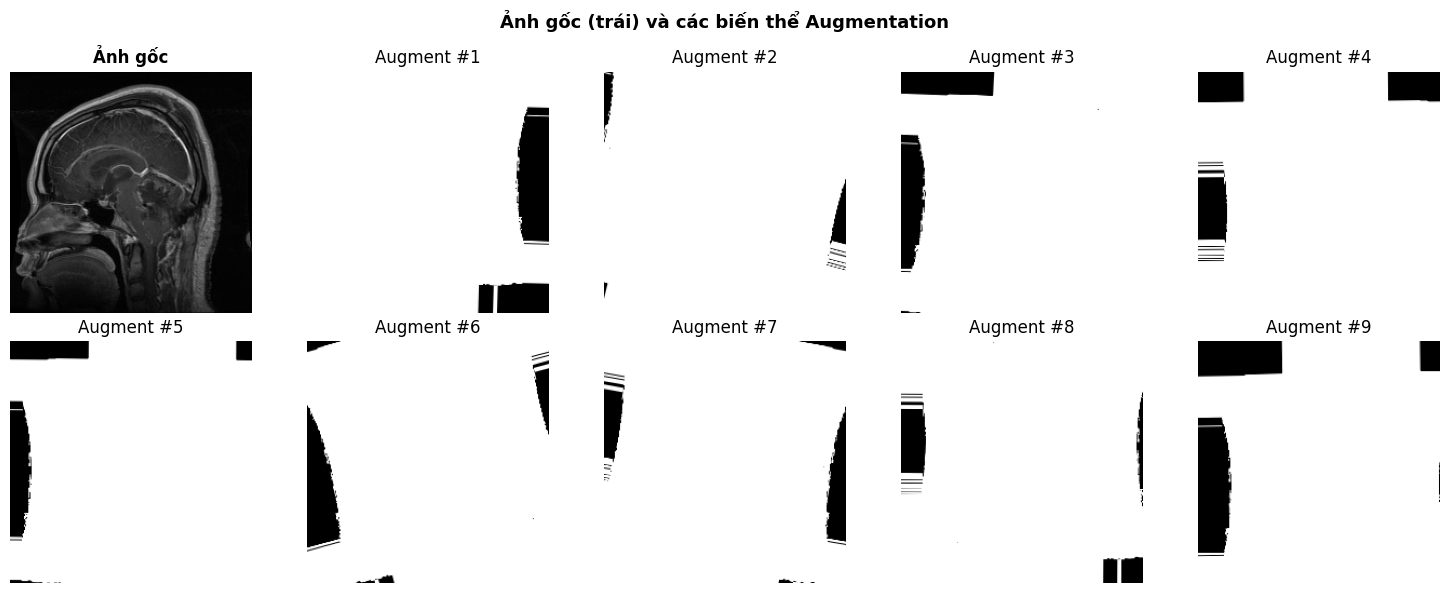

In [ ]:
# ============================================================
# Hiển thị ảnh gốc vs ảnh sau augmentation
# ============================================================
sample_path = df_train.iloc[0]['filepath']
sample_img  = cv2.imread(sample_path)
sample_img  = cv2.cvtColor(sample_img, cv2.COLOR_BGR2RGB)
sample_img  = cv2.resize(sample_img, IMG_SIZE)

# Tạo augmented versions
sample_arr = sample_img.reshape((1,) + sample_img.shape).astype('float32')
aug_gen = train_datagen.flow(sample_arr, batch_size=1)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Ảnh gốc (trái) và các biến thể Augmentation',
             fontsize=13, fontweight='bold')

# Hàng 1: ảnh gốc + augment #1-4
axes[0, 0].imshow(sample_img.astype('uint8'))
axes[0, 0].set_title('Ảnh gốc', fontweight='bold')
axes[0, 0].axis('off')

for j in range(1, 5):
    aug_img = next(aug_gen)[0]
    axes[0, j].imshow(np.clip(aug_img, 0, 255).astype('uint8'))  # ← sửa
    axes[0, j].set_title(f'Augment #{j}')
    axes[0, j].axis('off')

# Hàng 2: augment #5-9
for j in range(5):
    aug_img = next(aug_gen)[0]
    axes[1, j].imshow(np.clip(aug_img, 0, 255).astype('uint8'))  # ← sửa
    axes[1, j].set_title(f'Augment #{j+5}')
    axes[1, j].axis('off')

plt.tight_layout()
plt.savefig('preprocessing_augmentation.png', dpi=150, bbox_inches='tight')
plt.show()

## 💾 Phần G — Lưu thông tin để dùng ở các file sau

In [8]:
# ============================================================
# Lưu DataFrame để dùng lại ở file 03 và 04
# ============================================================
df_train.to_csv('df_train.csv', index=False)
df_val.to_csv('df_val.csv',     index=False)
df_test.to_csv('df_test.csv',   index=False)

print('💾 Đã lưu:')
print('   df_train.csv —', len(df_train), 'ảnh')
print('   df_val.csv   —', len(df_val),   'ảnh')
print('   df_test.csv  —', len(df_test),  'ảnh')
print()
print('✅ Preprocessing hoàn tất!')
print('   → Chuyển sang file 03_Model.ipynb để xây dựng mô hình')

💾 Đã lưu:
   df_train.csv — 2296 ảnh
   df_val.csv   — 574 ảnh
   df_test.csv  — 394 ảnh

✅ Preprocessing hoàn tất!
   → Chuyển sang file 03_Model.ipynb để xây dựng mô hình
